In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import numpy as np

# --- Helper Functions ---
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [ ]:
def initialize_parameters(layer_dims):
    parameters = {}
    for i in range(1, len(layer_dims)):
        parameters['W' + str(i)] = np.random.randn(layer_dims[i], layer_dims[i-1]) * np.sqrt(2 / layer_dims[i-1])
        parameters['b' + str(i)] = np.zeros((layer_dims[i], 1))
    return parameters

In [ ]:
def forward_propagation(X, parameters):
    cache = {'A0': X}
    A = X
    # Total number of layers (L = 3 for layer_dims [20, 16, 8, 3])
    L = len(parameters) // 2

    # Hidden layers (1 to L-1) using ReLU
    for l in range(1, L):
        W = parameters['W' + str(l)]
        b = parameters['b' + str(l)]
        Z = np.dot(W, A) + b
        A = relu(Z)

        cache['Z' + str(l)] = Z
        cache['A' + str(l)] = A

    # Output layer (L) using Softmax
    W = parameters['W' + str(L)]
    b = parameters['b' + str(L)]
    Z = np.dot(W, A) + b
    A = softmax(Z)

    cache['Z' + str(L)] = Z
    cache['A' + str(L)] = A

    return A, cache

In [ ]:
def compute_loss(A,y):
  m=y.shape[1]# no of trainign set/ex
  cross_entropy=np.sum(y * np.log(A + 1e-15))
  loss=-(1/m)*cross_entropy
  return loss


In [ ]:
# ye to bht mushkill hai -let's ai
def backward_propagation(A_last, Y, cache, parameters):
    grads = {}
    L = len(parameters) // 2
    m = Y.shape[1]

    # Output layer gradient (Softmax + Cross Entropy simplification)
    dZ = A_last - Y

    # Backpropagate through layers L down to 1
    for l in range(L, 0, -1):
        # Retrieve previous layer activation A_{l-1} from cache
        A_prev = cache['A' + str(l - 1)]

        # Calculate weight and bias gradients for current layer l
        grads['dW' + str(l)] = (1 / m) * np.dot(dZ, A_prev.T)
        grads['db' + str(l)] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

        # Calculate gradients for previous layer l-1 if we aren't at input layer
        if l > 1:
            W = parameters['W' + str(l)]
            dA_prev = np.dot(W.T, dZ)
            # Derivative of ReLU applied to Z_{l-1}
            dZ = dA_prev * relu_derivative(cache['Z' + str(l - 1)])

    return grads

In [ ]:
def update_parameters(p,grads,lr):
  L=len(p)//2
  for i in range(1,L+1):
    p['W'+str(i)]=p['W'+str(i)]-lr*grads['dW'+str(i)]
    p['b'+str(i)]=p['b'+str(i)]-lr*grads['db'+str(i)]
  return p


In [ ]:
def nn_model(X,Y,layer_dims,epochs,lr):
  parameters=initialize_parameters(layer_dims)
  costs = []
  for i in range(epochs):
    A,cache=forward_propagation(X,parameters)
    cost=compute_loss(A,Y)
    costs.append(cost)
    grads=backward_propagation(A,Y,cache,parameters)
    parameters=update_parameters(parameters,grads,lr)
    if i%100==0:
      print(f"epoch {i}- cost :{cost}")
  return parameters,costs

epoch 0- cost :1.6067204496529266
epoch 100- cost :1.1422171826982992
epoch 200- cost :1.055411751353212
epoch 300- cost :1.005754259787953
epoch 400- cost :0.9669008099541414
epoch 500- cost :0.9311180378608629
epoch 600- cost :0.8947100995818832
epoch 700- cost :0.8590560611589021
epoch 800- cost :0.8239286078898116
epoch 900- cost :0.7823820445287624


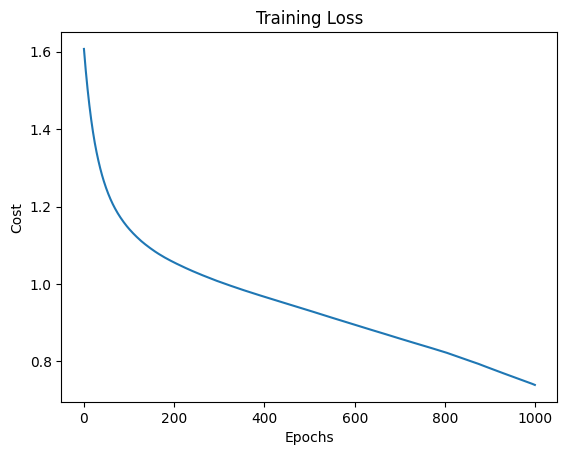

In [ ]:
# generate  some datset
np.random.seed(1) # fixes everything
X=np.random.randn(20,100)
Y=np.zeros((3,100))
Y[0, :33] = 1
Y[1, 33:66] = 1
Y[2, 66:] = 1

layer_dims=[20,16,8,3]
params, loss_history = nn_model(X, Y, layer_dims, epochs=1000, lr=0.01)

# 4. Plot loss over time
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

In [ ]:
def predict(X, Y, parameters):
    A, _ = forward_propagation(X, parameters)
    predictions = np.argmax(A, axis=0)
    labels = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == labels) * 100
    return predictions, accuracy
preds, acc = predict(X, Y, params)
print(f"Model Training Accuracy: {acc:.2f}%")

Model Training Accuracy: 73.00%
